In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# NEUROBRAIN FINALIZATION
# PROJECT SETUP


from pathlib import Path
import os
import sys
import subprocess
import json
import time
import shutil

PROJECT_ROOT = Path("/kaggle/working/neuroBrain")
REPO_URL = "https://github.com/ethicalcod/neuroBrain.git"


print("NEUROBRAIN — FINAL PROJECT SETUP")


# Remove an incomplete previous clone only if it exists


if PROJECT_ROOT.exists():

    print("Existing project directory found.")

    # If it is a Git repository, keep it.
    if (PROJECT_ROOT / ".git").exists():
        print("Existing Git repository will be reused.")

    else:
        print("Existing directory is not a Git repository.")
        print("Removing incomplete directory...")
        shutil.rmtree(PROJECT_ROOT)



# Clone repository

if not PROJECT_ROOT.exists():

    print("Cloning GitHub repository...")

    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(PROJECT_ROOT)
        ],
        check=True
    )

print()
print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

os.chdir(PROJECT_ROOT)

print()
print("Git status:")
subprocess.run(["git", "status"], check=False)

print()
print("Top-level project contents:")

for item in sorted(PROJECT_ROOT.iterdir()):
    print(" ", item.name)

print()
print("PROJECT SETUP COMPLETE")

NEUROBRAIN — FINAL PROJECT SETUP
Cloning GitHub repository...


Cloning into '/kaggle/working/neuroBrain'...



Project root: /kaggle/working/neuroBrain
Exists: True

Git status:
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

Top-level project contents:
  .git
  .gitignore
  LICENSE
  README.md
  docs
  figures
  models
  notebooks
  requirements.txt
  scripts
  src

PROJECT SETUP COMPLETE


In [2]:
# DEPENDENCIES + GPU

import subprocess
import sys
import torch
import numpy as np

print("NEUROBRAIN — DEPENDENCY AND GPU CHECK")

# Install project dependencies
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        "requirements.txt",
        "-q"
    ],
    check=True
)

import monai
import nibabel
import pandas
import matplotlib
import tqdm

print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("NumPy:", np.__version__)
print("Nibabel:", nibabel.__version__)

print()
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA version:",
        torch.version.cuda
    )

else:

    raise RuntimeError(
        "CUDA is not available. "
        "Enable GPU in Kaggle before continuing."
    )

print()
print("DEPENDENCIES AND GPU VERIFIED")

NEUROBRAIN — DEPENDENCY AND GPU CHECK
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.1 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
MONAI: 1.6.0
NumPy: 2.0.2
Nibabel: 5.4.2

CUDA available: True
GPU: Tesla T4
CUDA version: 12.8

DEPENDENCIES AND GPU VERIFIED


In [5]:
%cd /kaggle/working/neuroBrain

/kaggle/working


In [7]:
import os

print("Current directory:")
print(os.getcwd())

print("\nContents of /kaggle/working:")
print(os.listdir("/kaggle/working"))

Current directory:
/kaggle/working/neuroBrain

Contents of /kaggle/working:
['neuroBrain', '.virtual_documents']


In [9]:
%cd /kaggle/working/neuroBrain

/kaggle/working


In [10]:
!pwd

/kaggle/working/neuroBrain


In [11]:
import os

print("Current directory:", os.getcwd())
print("\n/kaggle/working contents:")
for item in os.listdir("/kaggle/working"):
    print(item)

Current directory: /kaggle/working/neuroBrain

/kaggle/working contents:
neuroBrain
.virtual_documents


In [12]:
import os

print("Current directory:")
print(os.getcwd())

print("\nContents of current directory:")
for item in os.listdir("."):
    print(item)

Current directory:
/kaggle/working/neuroBrain

Contents of current directory:
docs
requirements.txt
notebooks
models
figures
results
README.md
LICENSE
scripts
.gitignore
.git
src


In [13]:
%%writefile src/config.py

"""
NeuroBrain Project Configuration

This module centralizes project paths and global configuration.
"""

from pathlib import Path

# Project Paths

PROJECT_ROOT = Path(__file__).resolve().parent.parent

SRC_DIR = PROJECT_ROOT / "src"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
DOCS_DIR = PROJECT_ROOT / "docs"

# Dataset

DATASET_NAME = "Task01_BrainTumour"

DATASET_FILE_ID = "17kUAGnj5OhVj8yrAOae6a37jT10R01eX"

ARCHIVE_NAME = "Task01_BrainTumour.tar"

DATASET_ROOT = PROJECT_ROOT / DATASET_NAME

IMAGES_PATH = DATASET_ROOT / "imagesTr"
LABELS_PATH = DATASET_ROOT / "labelsTr"
TEST_IMAGES_PATH = DATASET_ROOT / "imagesTs"

DATASET_JSON = DATASET_ROOT / "dataset.json"

RANDOM_SEED = 42

# Training Placeholders

BATCH_SIZE = 2
NUM_WORKERS = 2

# Visualization

FIGURE_DPI = 300

# Model Configuration

IN_CHANNELS = 4
OUT_CHANNELS = 4

FEATURES = (16, 32, 64, 128, 256)

DROPOUT = 0.2

# Patch Sampling Configuration

PATCH_SIZE = (96, 96, 96)

NUM_SAMPLES = 2

Overwriting src/config.py


In [14]:
# PROJECT SETUP SCRIPT

import os
import subprocess

os.chdir("/kaggle/working/neuroBrain")

print("RUNNING PROJECT SETUP SCRIPT")

result = subprocess.run(
    [
        "python",
        "scripts/setup_project.py"
    ],
    text=True
)

if result.returncode != 0:
    raise RuntimeError(
        "setup_project.py failed."
    )

print()
print("PROJECT SETUP SCRIPT COMPLETED")

RUNNING PROJECT SETUP SCRIPT


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17kUAGnj5OhVj8yrAOae6a37jT10R01eX
From (redirected): https://drive.google.com/uc?id=17kUAGnj5OhVj8yrAOae6a37jT10R01eX&confirm=t&uuid=aeec78e0-0362-486d-835b-e99d09ea625d
To: /kaggle/working/neuroBrain/Task01_BrainTumour.tar
100%|██████████| 7.61G/7.61G [01:09<00:00, 110MB/s] 
/kaggle/working/neuroBrain/scripts/setup_dataset.py:65: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(PROJECT_ROOT)


Download complete.
Extracting archive...
Extraction complete.
Archive removed.

 Dataset setup completed successfully.
NeuroBrain Project Verification
Project Root Exists!
Dataset Exists!
imagesTr Exists!
labelsTr Exists!
dataset.json Exists!
docs Exists!
figures Exists!
models Exists!
notebooks Exists!
results Exists!
scripts Exists!
src Exists!
 Everything looks good!

PROJECT SETUP SCRIPT COMPLETED


In [15]:
#DATASET VERIFICATION


from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/neuroBrain")
DATASET_ROOT = PROJECT_ROOT / "Task01_BrainTumour"

print("neuroBrain — DATASET VERIFICATION")

assert DATASET_ROOT.exists(), (
    f"Dataset not found: {DATASET_ROOT}"
)

IMAGES_DIR = DATASET_ROOT / "imagesTr"
LABELS_DIR = DATASET_ROOT / "labelsTr"

def valid_nii_files(directory):
    return sorted([
        p for p in directory.glob("*.nii.gz")
        if not p.name.startswith("._")
    ])

image_files = valid_nii_files(IMAGES_DIR)
label_files = valid_nii_files(LABELS_DIR)

print("Dataset root:", DATASET_ROOT)
print("Valid training images:", len(image_files))
print("Valid training labels:", len(label_files))

assert len(image_files) == 484
assert len(label_files) == 484

image_ids = {
    p.name.replace(".nii.gz", "")
    for p in image_files
}

label_ids = {
    p.name.replace(".nii.gz", "")
    for p in label_files
}

assert image_ids == label_ids

print()
print("Dataset verification PASSED")
print("Patients:", len(image_ids))

neuroBrain — DATASET VERIFICATION
Dataset root: /kaggle/working/neuroBrain/Task01_BrainTumour
Valid training images: 484
Valid training labels: 484

Dataset verification PASSED
Patients: 484


In [16]:
# EXACT DATASET + 387/97 SPLIT

import random
import numpy as np
import torch
import nibabel as nib

from torch.utils.data import Dataset, DataLoader, Subset

RANDOM_SEED = 42

BATCH_SIZE = 2
NUM_WORKERS = 2

IN_CHANNELS = 4
OUT_CHANNELS = 4

PATCH_SIZE = (96, 96, 96)


print("RECREATING EXACT TRAIN / VALIDATION SPLIT")

# Deterministic seed

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# Normalization

def normalize_nonzero(volume):

    normalized = (
        volume
        .copy()
        .astype(np.float32)
    )

    mask = volume > 0

    if np.any(mask):

        mean = volume[mask].mean()
        std = volume[mask].std()

        if std > 0:
            normalized[mask] = (
                volume[mask] - mean
            ) / std

    return normalized


# Patient records

def get_patient_records():

    image_files = sorted([
        p for p in IMAGES_DIR.glob("*.nii.gz")
        if not p.name.startswith("._")
    ])

    label_files = sorted([
        p for p in LABELS_DIR.glob("*.nii.gz")
        if not p.name.startswith("._")
    ])

    label_map = {
        p.name: p
        for p in label_files
    }

    records = []

    for image_path in image_files:

        if image_path.name not in label_map:
            raise FileNotFoundError(
                f"Missing label for {image_path.name}"
            )

        patient_id = image_path.name.replace(
            ".nii.gz",
            ""
        )

        records.append({
            "patient_id": patient_id,
            "image": str(image_path),
            "label": str(
                label_map[image_path.name]
            )
        })

    return records


PATIENT_RECORDS = get_patient_records()

print("Total patient records:", len(PATIENT_RECORDS))

assert len(PATIENT_RECORDS) == 484


# Dataset

class BrainTumourDataset(Dataset):

    def __init__(self):

        self.records = PATIENT_RECORDS

    def __len__(self):

        return len(self.records)

    def __getitem__(self, index):

        patient = self.records[index]

        image = (
            nib.load(patient["image"])
            .get_fdata()
            .astype("float32")
        )

        # Normalize each MRI modality
        for channel in range(image.shape[-1]):

            image[:, :, :, channel] = (
                normalize_nonzero(
                    image[:, :, :, channel]
                )
            )

        label = (
            nib.load(patient["label"])
            .get_fdata()
            .astype("uint8")
        )

        # H W D C -> C H W D
        image = image.transpose(
            3, 0, 1, 2
        )

        image = torch.from_numpy(
            image
        ).float()

        label = torch.from_numpy(
            label
        ).long()

        return {
            "patient_id": patient["patient_id"],
            "image": image,
            "label": label
        }


# Exact random split

full_dataset = BrainTumourDataset()

generator = torch.Generator().manual_seed(
    RANDOM_SEED
)

indices = torch.randperm(
    len(full_dataset),
    generator=generator
).tolist()

train_size = int(
    0.8 * len(full_dataset)
)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

print()
print("Training patients:", len(train_indices))
print("Validation patients:", len(val_indices))

assert len(train_indices) == 387
assert len(val_indices) == 97


train_dataset = Subset(
    full_dataset,
    train_indices
)

val_dataset = Subset(
    full_dataset,
    val_indices
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print()
print("DataLoaders created.")
print("Train:", len(train_loader.dataset))
print("Validation:", len(val_loader.dataset))

assert len(val_loader.dataset) == 97

RECREATING EXACT TRAIN / VALIDATION SPLIT
Total patient records: 484

Training patients: 387
Validation patients: 97

DataLoaders created.
Train: 387
Validation: 97


In [18]:
# HUGGING FACE RESTORE


import os
import json

from huggingface_hub import (
    login,
    hf_hub_download
)

print("HUGGING FACE — RESTORING EXPERIMENT")

# Get HF token from Kaggle secret

HF_TOKEN = os.environ.get(
    "HF_TOKEN"
)

if HF_TOKEN is None:

    try:

        from kaggle_secrets import (
            UserSecretsClient
        )

        secrets = UserSecretsClient()

        HF_TOKEN = secrets.get_secret(
            "HF_TOKEN"
        )

    except Exception as e:

        raise RuntimeError(
            "HF_TOKEN was not found.\n"
            "Add your Hugging Face token as a "
            "Kaggle Secret named HF_TOKEN, "
            "then rerun this cell."
        )


login(
    token=HF_TOKEN,
    add_to_git_credential=False
)

HF_REPO_ID = "shashik-bits/neuroBrain-checkpoints"

# Best checkpoint

BEST_CHECKPOINT = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename="formal_experiment/best_model.pt",
    repo_type="model"
)

print()
print("Best checkpoint downloaded:")
print(BEST_CHECKPOINT)

# Latest checkpoint

LATEST_CHECKPOINT = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename="formal_experiment/latest.pt",
    repo_type="model"
)

print()
print("Latest checkpoint downloaded:")
print(LATEST_CHECKPOINT)

# Training history

TRAINING_HISTORY_PATH = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename="formal_experiment/training_history.json",
    repo_type="model"
)

print()
print("Training history downloaded:")
print(TRAINING_HISTORY_PATH)

# Inspect checkpoint metadata

checkpoint_preview = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu"
)

print()
print("CHECKPOINT METADATA")

print(
    "Epoch:",
    checkpoint_preview.get("epoch")
)

print(
    "Best metric:",
    checkpoint_preview.get(
        "best_metric"
    )
)

assert checkpoint_preview["epoch"] == 18


# Inspect history

with open(
    TRAINING_HISTORY_PATH,
    "r"
) as f:

    training_history = json.load(f)

print()
print("Training history type:")
print(type(training_history))

if isinstance(
    training_history,
    dict
):

    print(
        "History keys:",
        list(training_history.keys())
    )

elif isinstance(
    training_history,
    list
):

    print(
        "History entries:",
        len(training_history)
    )

    if len(training_history) > 0:

        print(
            "First entry:",
            training_history[0]
        )

print()
print("HUGGING FACE RESTORE COMPLETE")

HUGGING FACE — RESTORING EXPERIMENT


formal_experiment/best_model.pt:   0%|          | 0.00/57.8M [00:00<?, ?B/s]


Best checkpoint downloaded:
/root/.cache/huggingface/hub/models--shashik-bits--neuroBrain-checkpoints/snapshots/fef73dd3bd34aebfbc808e35ce30603c3986853e/formal_experiment/best_model.pt


formal_experiment/latest.pt:   0%|          | 0.00/57.8M [00:00<?, ?B/s]


Latest checkpoint downloaded:
/root/.cache/huggingface/hub/models--shashik-bits--neuroBrain-checkpoints/snapshots/fef73dd3bd34aebfbc808e35ce30603c3986853e/formal_experiment/latest.pt


training_history.json: 0.00B [00:00, ?B/s]


Training history downloaded:
/root/.cache/huggingface/hub/models--shashik-bits--neuroBrain-checkpoints/snapshots/fef73dd3bd34aebfbc808e35ce30603c3986853e/formal_experiment/training_history.json

CHECKPOINT METADATA
Epoch: 18
Best metric: 0.7628627273340508

Training history type:
<class 'dict'>
History keys: ['epoch', 'train_loss', 'val_loss', 'class_0_dice', 'class_1_dice', 'class_2_dice', 'class_3_dice', 'WT_dice', 'TC_dice', 'ET_dice', 'mean_tumor_dice', 'learning_rate']

HUGGING FACE RESTORE COMPLETE


In [19]:
# MODEL RESTORATION

import torch
import torch.nn as nn

from monai.networks.nets import UNet

# Device

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("MODEL RESTORATION")

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# Model

class NeuroBrainUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = UNet(
            spatial_dims=3,
            in_channels=4,
            out_channels=4,
            channels=(
                16,
                32,
                64,
                128,
                256
            ),
            strides=(
                2,
                2,
                2,
                2
            ),
            num_res_units=2,
            dropout=0.2,
        )

    def forward(self, x):

        return self.model(x)


model = NeuroBrainUNet().to(device)


# Load Epoch 18

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

# Verify

parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

print()
print("Checkpoint epoch:")
print(
    checkpoint["epoch"]
)

print("Checkpoint best metric:")
print(
    checkpoint["best_metric"]
)

print("Parameters:")
print(
    f"{parameter_count:,}"
)

assert checkpoint["epoch"] == 18

assert (
    parameter_count == 4_811_129
)

print()
print("EPOCH-18 MODEL RESTORED SUCCESSFULLY")

MODEL RESTORATION
Device: cuda
GPU: Tesla T4

Checkpoint epoch:
18
Checkpoint best metric:
0.7628627273340508
Parameters:
4,811,129

EPOCH-18 MODEL RESTORED SUCCESSFULLY


In [20]:
# VALIDATION SANITY CHECK

print("VALIDATION SANITY CHECK")

batch = next(iter(val_loader))

print(
    "Image shape:",
    batch["image"].shape
)

print(
    "Label shape:",
    batch["label"].shape
)

print(
    "Patient IDs:",
    batch["patient_id"]
)

assert (
    batch["image"].shape[1]
    == 4
)

assert (
    batch["label"].ndim
    == 4
)

assert (
    len(val_loader.dataset)
    == 97
)

print()
print("VALIDATION SANITY CHECK PASSED")

VALIDATION SANITY CHECK
Image shape: torch.Size([2, 4, 240, 240, 155])
Label shape: torch.Size([2, 240, 240, 155])
Patient IDs: ['BRATS_001', 'BRATS_142']

VALIDATION SANITY CHECK PASSED


In [21]:
# PERSISTENT FINAL EVALUATION SYSTEM

from pathlib import Path
import json
import time
import numpy as np
import shutil

FINAL_EVAL_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FINAL_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PATIENT_RESULTS_PATH = (
    FINAL_EVAL_DIR
    / "patient_metrics.json"
)

PROGRESS_PATH = (
    FINAL_EVAL_DIR
    / "evaluation_progress.json"
)

FINAL_METRICS_PATH = (
    FINAL_EVAL_DIR
    / "final_metrics.json"
)

SUMMARY_PATH = (
    FINAL_EVAL_DIR
    / "evaluation_summary.txt"
)

print("PERSISTENT EVALUATION DIRECTORY")

print(
    FINAL_EVAL_DIR
)

print()
print("Existing files:")

for p in sorted(
    FINAL_EVAL_DIR.iterdir()
):

    print(
        " ",
        p.name
    )


# Dice

def binary_dice(
    pred_mask,
    true_mask
):

    pred_mask = np.asarray(
        pred_mask,
        dtype=bool
    )

    true_mask = np.asarray(
        true_mask,
        dtype=bool
    )

    pred_sum = pred_mask.sum()
    true_sum = true_mask.sum()

    if (
        pred_sum == 0
        and true_sum == 0
    ):
        return 1.0

    if (
        pred_sum + true_sum
        == 0
    ):
        return 1.0

    intersection = np.logical_and(
        pred_mask,
        true_mask
    ).sum()

    return float(
        2.0
        * intersection
        / (pred_sum + true_sum)
    )


def calculate_patient_metrics(
    prediction,
    ground_truth
):

    prediction = np.asarray(
        prediction,
        dtype=np.uint8
    )

    ground_truth = np.asarray(
        ground_truth,
        dtype=np.uint8
    )

    metrics = {}

    for class_id in range(4):

        metrics[
            f"class_{class_id}_dice"
        ] = binary_dice(
            prediction == class_id,
            ground_truth == class_id
        )

    metrics["WT_dice"] = binary_dice(
        prediction > 0,
        ground_truth > 0
    )

    metrics["TC_dice"] = binary_dice(
        np.isin(
            prediction,
            [2, 3]
        ),
        np.isin(
            ground_truth,
            [2, 3]
        )
    )

    metrics["ET_dice"] = binary_dice(
        prediction == 3,
        ground_truth == 3
    )

    metrics["mean_tumor_dice"] = float(
        np.mean([
            metrics["class_1_dice"],
            metrics["class_2_dice"],
            metrics["class_3_dice"],
        ])
    )

    return metrics


# Local persistence

def load_patient_results():

    if not PATIENT_RESULTS_PATH.exists():

        return {}

    with open(
        PATIENT_RESULTS_PATH,
        "r"
    ) as f:

        data = json.load(f)

    if not isinstance(
        data,
        dict
    ):

        raise ValueError(
            "patient_metrics.json "
            "has invalid format."
        )

    return data


def save_patient_results(
    results
):

    temporary = (
        FINAL_EVAL_DIR
        / "patient_metrics.tmp.json"
    )

    with open(
        temporary,
        "w"
    ) as f:

        json.dump(
            results,
            f,
            indent=2
        )

    temporary.replace(
        PATIENT_RESULTS_PATH
    )


def save_progress(
    completed,
    total
):

    progress = {

        "completed_patients":
            completed,

        "total_patients":
            total,

        "remaining_patients":
            total - completed,

        "last_updated":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            )
    }

    temporary = (
        FINAL_EVAL_DIR
        / "evaluation_progress.tmp.json"
    )

    with open(
        temporary,
        "w"
    ) as f:

        json.dump(
            progress,
            f,
            indent=2
        )

    temporary.replace(
        PROGRESS_PATH
    )


print()
print("Persistence functions ready.")

PERSISTENT EVALUATION DIRECTORY
/kaggle/working/neuroBrain/results/final_evaluation

Existing files:

Persistence functions ready.


In [25]:
# HUGGING FACE BACKUP FUNCTION

from huggingface_hub import HfApi

HF_API = HfApi(
    token=HF_TOKEN
)

HF_EVAL_DIR = "formal_experiment/final_evaluation"


def backup_evaluation_to_hf(include_summary=True):

    print("\nHUGGING FACE BACKUP")
    print("-------------------")

    files_to_upload = [
        (
            PATIENT_RESULTS_PATH,
            "patient_metrics.json"
        ),
        (
            PROGRESS_PATH,
            "evaluation_progress.json"
        ),
    ]

    if FINAL_METRICS_PATH.exists():
        files_to_upload.append(
            (
                FINAL_METRICS_PATH,
                "final_metrics.json"
            )
        )

    if include_summary and SUMMARY_PATH.exists():
        files_to_upload.append(
            (
                SUMMARY_PATH,
                "evaluation_summary.txt"
            )
        )

    print("Files to upload:")

    for local_path, remote_name in files_to_upload:
        print(
            f"  {remote_name}: "
            f"{local_path} "
            f"(exists={local_path.exists()})"
        )

    print()

    for local_path, remote_name in files_to_upload:

        if not local_path.exists():
            print(
                f"Skipping {remote_name}: "
                f"file does not exist."
            )
            continue

        print(f"Uploading: {remote_name}")
        print(f"Local path: {local_path}")
        print(
            f"Remote path: "
            f"{HF_EVAL_DIR}/{remote_name}"
        )

        try:

            result = HF_API.upload_file(
                path_or_fileobj=str(local_path),
                path_in_repo=(
                    f"{HF_EVAL_DIR}/"
                    f"{remote_name}"
                ),
                repo_id=HF_REPO_ID,
                repo_type="model",
                commit_message=(
                    "Update final validation artifacts"
                ),
            )

            print(
                f"Upload successful: {remote_name}"
            )
            print(
                f"Result: {result}"
            )

        except Exception as e:

            print(
                f"ERROR uploading {remote_name}"
            )
            print(
                f"{type(e).__name__}: {e}"
            )

            raise

    print()
    print("Hugging Face backup complete.")

In [26]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi

user_secrets = UserSecretsClient()

HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

HF_API = HfApi(token=HF_TOKEN)

print("HF token loaded:", HF_TOKEN is not None)

HF token loaded: True


In [27]:
user = HF_API.whoami()

print("Hugging Face authentication successful.")
print("Username:", user["name"])

Hugging Face authentication successful.
Username: shashik-bits


In [28]:
print("HF_REPO_ID:", HF_REPO_ID)

HF_REPO_ID: shashik-bits/neuroBrain-checkpoints


In [29]:
repo_info = HF_API.repo_info(
    repo_id=HF_REPO_ID,
    repo_type="model"
)

print("Repository exists:")
print(repo_info.id)

Repository exists:
shashik-bits/neuroBrain-checkpoints


In [30]:
from pathlib import Path

test_file = Path("/kaggle/working/hf_test.txt")

test_file.write_text(
    "Hugging Face upload test successful."
)

print("Starting test upload...")

HF_API.upload_file(
    path_or_fileobj=str(test_file),
    path_in_repo="test/hf_test.txt",
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message="Test Hugging Face upload",
)

print("Test upload completed successfully.")

Starting test upload...
Test upload completed successfully.


In [34]:

# HUGGING FACE BACKUP FUNCTION


from huggingface_hub import HfApi

HF_API = HfApi(
    token=HF_TOKEN
)

HF_EVAL_DIR = (
    "formal_experiment/"
    "final_evaluation"
)


def backup_evaluation_to_hf(
    include_summary=True
):

    print()

    print("HUGGING FACE BACKUP")


    files_to_upload = [
        (
            PATIENT_RESULTS_PATH,
            "patient_metrics.json"
        ),
        (
            PROGRESS_PATH,
            "evaluation_progress.json"
        ),
    ]

    if FINAL_METRICS_PATH.exists():

        files_to_upload.append(
            (
                FINAL_METRICS_PATH,
                "final_metrics.json"
            )
        )

    if (
        include_summary
        and SUMMARY_PATH.exists()
    ):

        files_to_upload.append(
            (
                SUMMARY_PATH,
                "evaluation_summary.txt"
            )
        )

    for local_path, remote_name in files_to_upload:

        if not local_path.exists():

            continue

        print(
            "Uploading:",
            remote_name
        )

        HF_API.upload_file(
            path_or_fileobj=str(
                local_path
            ),
            path_in_repo=(
                f"{HF_EVAL_DIR}/"
                f"{remote_name}"
            ),
            repo_id=HF_REPO_ID,
            repo_type="model",
            commit_message=(
                "Update final validation artifacts"
            ),
        )

    print(
        "Hugging Face backup complete."
    )

In [35]:
# FINAL 97-PATIENT VALIDATION

import time
import numpy as np
import torch

from tqdm.auto import tqdm
from monai.inferers import sliding_window_inference


ROI_SIZE = (
    96,
    96,
    96
)

SW_BATCH_SIZE = 1

OVERLAP = 0.25

TOTAL_PATIENTS = len(
    val_loader.dataset
)

assert (
    TOTAL_PATIENTS == 97
)

patient_results = (
    load_patient_results()
)

completed_ids = set(
    patient_results.keys()
)

print("neuroBrain — FINAL VALIDATION")

print(
    "Checkpoint:",
    checkpoint["epoch"]
)

print(
    "Patients already completed:",
    len(completed_ids)
)

print(
    "Patients remaining:",
    97 - len(completed_ids)
)

print(
    "ROI:",
    ROI_SIZE
)

print(
    "Overlap:",
    OVERLAP
)

print()


evaluation_start = time.time()

model.eval()


with torch.no_grad():

    progress_bar = tqdm(
        total=TOTAL_PATIENTS,
        initial=len(
            patient_results
        ),
        desc="97-patient validation",
        unit="patient"
    )

    for batch in val_loader:

        images = batch["image"]

        labels = batch["label"]

        patient_ids = (
            batch["patient_id"]
        )

        batch_size = (
            images.shape[0]
        )


        for i in range(
            batch_size
        ):

            patient_id = str(
                patient_ids[i]
            )


            # RESUME SAFETY

            if (
                patient_id
                in patient_results
            ):

                continue


            # Prepare patient

            image = (
                images[i:i+1]
                .to(
                    device,
                    non_blocking=True
                )
            )

            label = (
                labels[i]
                .cpu()
                .numpy()
            )


            # Sliding-window inference

            prediction_logits = (
                sliding_window_inference(
                    inputs=image,
                    roi_size=ROI_SIZE,
                    sw_batch_size=SW_BATCH_SIZE,
                    predictor=model,
                    overlap=OVERLAP,
                )
            )


            prediction = (
                torch.argmax(
                    prediction_logits,
                    dim=1
                )[0]
            )


            prediction = (
                prediction
                .detach()
                .cpu()
                .numpy()
                .astype(np.uint8)
            )


            # Metrics

            metrics = (
                calculate_patient_metrics(
                    prediction=prediction,
                    ground_truth=label
                )
            )


            patient_results[
                patient_id
            ] = {
                "patient_id":
                    patient_id,

                **metrics
            }


            # SAVE IMMEDIATELY

            save_patient_results(
                patient_results
            )

            save_progress(
                completed=len(
                    patient_results
                ),
                total=TOTAL_PATIENTS
            )


            # Every 5 patients:
            # BACKUP TO HUGGING FACE

            completed_count = (
                len(patient_results)
            )

            if (
                completed_count % 5 == 0
            ):

                backup_evaluation_to_hf(
                    include_summary=False
                )


            # Memory cleanup

            del image

            del prediction_logits

            del prediction

            if torch.cuda.is_available():

                torch.cuda.empty_cache()


            # Progress display

            progress_bar.update(1)


            current_mean = np.mean([
                x[
                    "mean_tumor_dice"
                ]
                for x
                in patient_results.values()
            ])


            elapsed = (
                time.time()
                - evaluation_start
            )


            completed_count = (
                len(patient_results)
            )


            if completed_count > 0:

                avg_time = (
                    elapsed
                    / completed_count
                )

                remaining = (
                    TOTAL_PATIENTS
                    - completed_count
                )

                eta_minutes = (
                    remaining
                    * avg_time
                    / 60
                )

            else:

                eta_minutes = 0


            progress_bar.set_postfix(
                mean_dice=(
                    f"{current_mean:.4f}"
                ),
                remaining=(
                    TOTAL_PATIENTS
                    - completed_count
                ),
                eta=(
                    f"{eta_minutes:.1f}m"
                )
            )


    progress_bar.close()


# Final local verification

patient_results = (
    load_patient_results()
)

print()

print("VALIDATION COMPLETE")

print(
    "Patients evaluated:",
    len(patient_results),
    "/ 97"
)

assert (
    len(patient_results)
    == 97
)

print(
    "ALL 97 PATIENTS COMPLETED."
)

neuroBrain — FINAL VALIDATION
Checkpoint: 18
Patients already completed: 0
Patients remaining: 97
ROI: (96, 96, 96)
Overlap: 0.25



97-patient validation:   0%|          | 0/97 [00:00<?, ?patient/s]


HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.json
Uploading: evaluation_progress.json
Hugging Face backup complete.

HUGGING FACE BACKUP
Uploading: patient_metrics.

In [36]:
# FINAL METRICS

import json
import numpy as np
import pandas as pd


metric_names = [
    "class_0_dice",
    "class_1_dice",
    "class_2_dice",
    "class_3_dice",
    "WT_dice",
    "TC_dice",
    "ET_dice",
    "mean_tumor_dice",
]


final_metrics = {}


for metric_name in metric_names:

    values = np.array([
        float(
            result[metric_name]
        )
        for result
        in patient_results.values()
    ])

    final_metrics[
        metric_name
    ] = {

        "mean":
            float(
                np.mean(values)
            ),

        "std":
            float(
                np.std(values)
            ),

        "min":
            float(
                np.min(values)
            ),

        "max":
            float(
                np.max(values)
            ),
    }


final_metrics[
    "metadata"
] = {

    "checkpoint_epoch":
        int(
            checkpoint["epoch"]
        ),

    "checkpoint_best_metric":
        float(
            checkpoint[
                "best_metric"
            ]
        ),

    "num_validation_patients":
        97,

    "roi_size":
        list(ROI_SIZE),

    "sw_batch_size":
        SW_BATCH_SIZE,

    "overlap":
        OVERLAP,

    "random_seed":
        RANDOM_SEED,
}


# Save JSON

with open(
    FINAL_METRICS_PATH,
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2
    )


# Human-readable summary

summary_lines = []

summary_lines.append(
    "neuroBrain — FINAL 97-PATIENT VALIDATION"
)

summary_lines.append(
    "*" * 50
)

summary_lines.append(
    f"Selected checkpoint: "
    f"Epoch {checkpoint['epoch']}"
)

summary_lines.append(
    f"Checkpoint best metric: "
    f"{checkpoint['best_metric']:.10f}"
)

summary_lines.append(
    "Patients evaluated: 97 / 97"
)

summary_lines.append(
    f"ROI size: {ROI_SIZE}"
)

summary_lines.append(
    f"Sliding-window overlap: {OVERLAP}"
)

summary_lines.append("")

summary_lines.append(
    "Metric results:"
)

summary_lines.append("")

display_rows = [

    (
        "Background",
        "class_0_dice"
    ),

    (
        "Edema",
        "class_1_dice"
    ),

    (
        "Non-enhancing tumor",
        "class_2_dice"
    ),

    (
        "Enhancing tumor",
        "class_3_dice"
    ),

    (
        "Whole Tumor (WT)",
        "WT_dice"
    ),

    (
        "Tumor Core (TC)",
        "TC_dice"
    ),

    (
        "Enhancing Tumor (ET)",
        "ET_dice"
    ),

    (
        "Mean Tumor Dice",
        "mean_tumor_dice"
    ),
]


table_rows = []


for label, key in display_rows:

    result = (
        final_metrics[key]
    )

    summary_lines.append(
        f"{label}: "
        f"{result['mean']:.6f} "
        f"+/- "
        f"{result['std']:.6f}"
    )

    table_rows.append({

        "Metric":
            label,

        "Mean Dice":
            result["mean"],

        "Std":
            result["std"],

        "Min":
            result["min"],

        "Max":
            result["max"],
    })


summary_lines.append("")

summary_lines.append(
    "Mean Tumor Dice = mean of "
    "class 1, class 2, and class 3 Dice."
)

summary_lines.append(
    "Checkpoint selection metric is based "
    "on WT/TC/ET and is reported separately."
)

summary_lines.append("")

summary_lines.append(
    "These are validation-set results from "
    "97 patients, not hidden test-set results."
)


with open(
    SUMMARY_PATH,
    "w"
) as f:

    f.write(
        "\n".join(summary_lines)
    )

# Display table

results_table = pd.DataFrame(
    table_rows
)

display(
    results_table.style.format({
        "Mean Dice":
            "{:.4f}",

        "Std":
            "{:.4f}",

        "Min":
            "{:.4f}",

        "Max":
            "{:.4f}",
    })
)


print()
print(
    "\n".join(summary_lines)
)

,Metric,Mean Dice,Std,Min,Max
0,Background,0.9988,0.0007,0.9964,0.9998
1,Edema,0.7061,0.1401,0.2466,0.9096
2,Non-enhancing tumor,0.4738,0.2450,0.0000,0.9537
3,Enhancing tumor,0.7106,0.2375,0.0000,0.9348
4,Whole Tumor (WT),0.8450,0.1106,0.3540,0.9679
5,Tumor Core (TC),0.7352,0.2028,0.0769,0.9690
6,Enhancing Tumor (ET),0.7106,0.2375,0.0000,0.9348
7,Mean Tumor Dice,0.6302,0.1436,0.1426,0.8690



neuroBrain — FINAL 97-PATIENT VALIDATION
**************************************************
Selected checkpoint: Epoch 18
Checkpoint best metric: 0.7628627273
Patients evaluated: 97 / 97
ROI size: (96, 96, 96)
Sliding-window overlap: 0.25

Metric results:

Background: 0.998762 +/- 0.000723
Edema: 0.706147 +/- 0.140100
Non-enhancing tumor: 0.473783 +/- 0.244984
Enhancing tumor: 0.710570 +/- 0.237510
Whole Tumor (WT): 0.845034 +/- 0.110645
Tumor Core (TC): 0.735166 +/- 0.202817
Enhancing Tumor (ET): 0.710570 +/- 0.237510
Mean Tumor Dice: 0.630167 +/- 0.143570

Mean Tumor Dice = mean of class 1, class 2, and class 3 Dice.
Checkpoint selection metric is based on WT/TC/ET and is reported separately.

These are validation-set results from 97 patients, not hidden test-set results.


In [37]:
# FINAL RESULTS CSV

RESULTS_CSV = (
    FINAL_EVAL_DIR
    / "final_metrics_table.csv"
)

results_table.to_csv(
    RESULTS_CSV,
    index=False
)

print(
    "Saved:",
    RESULTS_CSV
)

Saved: /kaggle/working/neuroBrain/results/final_evaluation/final_metrics_table.csv


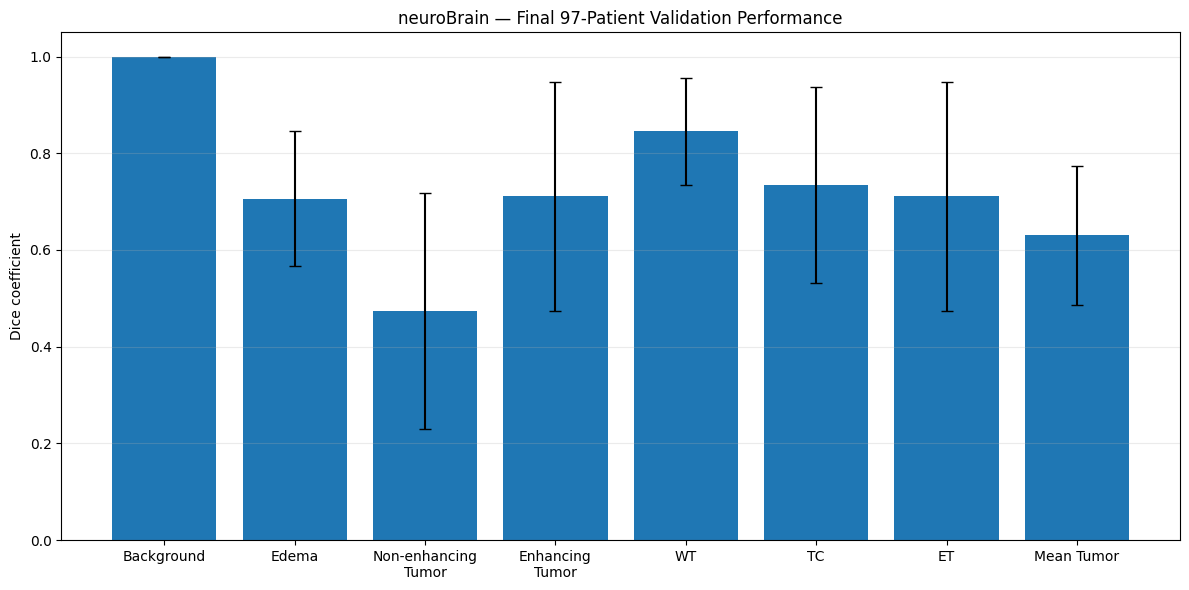

Saved: /kaggle/working/neuroBrain/figures/06_final_validation_dice.png


In [38]:
# FIGURE 06
# FINAL VALIDATION DICE

import matplotlib.pyplot as plt
import numpy as np

FIGURES_DIR = (
    PROJECT_ROOT / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


labels = [
    "Background",
    "Edema",
    "Non-enhancing\nTumor",
    "Enhancing\nTumor",
    "WT",
    "TC",
    "ET",
    "Mean Tumor",
]


keys = [
    "class_0_dice",
    "class_1_dice",
    "class_2_dice",
    "class_3_dice",
    "WT_dice",
    "TC_dice",
    "ET_dice",
    "mean_tumor_dice",
]


means = [
    final_metrics[k]["mean"]
    for k in keys
]

stds = [
    final_metrics[k]["std"]
    for k in keys
]


plt.figure(
    figsize=(12, 6)
)

x = np.arange(
    len(labels)
)

plt.bar(
    x,
    means,
    yerr=stds,
    capsize=4
)

plt.xticks(
    x,
    labels
)

plt.ylabel(
    "Dice coefficient"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "neuroBrain — Final 97-Patient Validation Performance"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

path = (
    FIGURES_DIR
    / "06_final_validation_dice.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

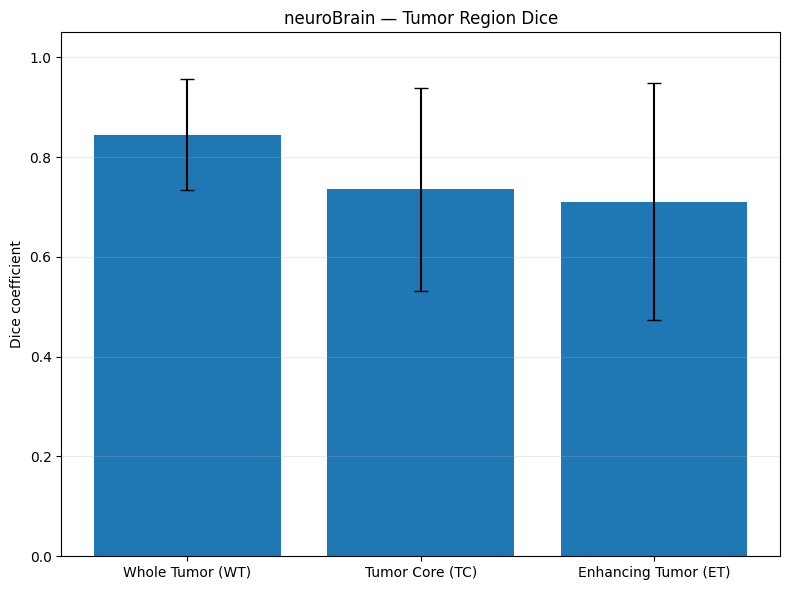

Saved: /kaggle/working/neuroBrain/figures/07_tumor_region_dice.png


In [39]:
# FIGURE 07
# WT / TC / ET

labels = [
    "Whole Tumor (WT)",
    "Tumor Core (TC)",
    "Enhancing Tumor (ET)"
]

keys = [
    "WT_dice",
    "TC_dice",
    "ET_dice"
]

means = [
    final_metrics[k]["mean"]
    for k in keys
]

stds = [
    final_metrics[k]["std"]
    for k in keys
]


plt.figure(
    figsize=(8, 6)
)

x = np.arange(
    len(labels)
)

plt.bar(
    x,
    means,
    yerr=stds,
    capsize=5
)

plt.xticks(
    x,
    labels
)

plt.ylabel(
    "Dice coefficient"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "neuroBrain — Tumor Region Dice"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

path = (
    FIGURES_DIR
    / "07_tumor_region_dice.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

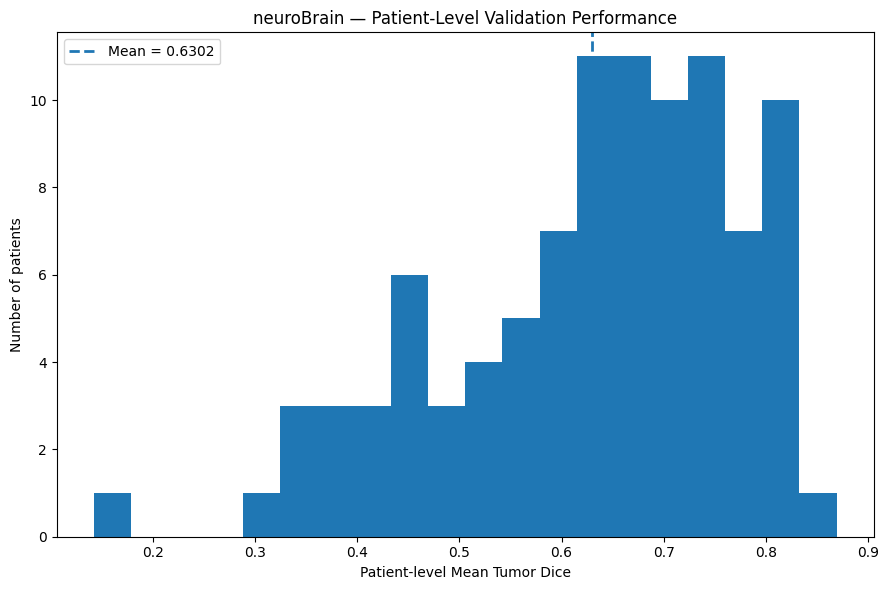

Saved: /kaggle/working/neuroBrain/figures/08_patient_dice_distribution.png


In [40]:
# FIGURE 08
# PATIENT-LEVEL DICE DISTRIBUTION


patient_dice = np.array([
    x["mean_tumor_dice"]
    for x
    in patient_results.values()
])


plt.figure(
    figsize=(9, 6)
)

plt.hist(
    patient_dice,
    bins=20
)

plt.axvline(
    patient_dice.mean(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean = "
        f"{patient_dice.mean():.4f}"
    )
)

plt.xlabel(
    "Patient-level Mean Tumor Dice"
)

plt.ylabel(
    "Number of patients"
)

plt.title(
    "neuroBrain — Patient-Level Validation Performance"
)

plt.legend()

plt.tight_layout()

path = (
    FIGURES_DIR
    / "08_patient_dice_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

TRAINING HISTORY
Type: <class 'dict'>

History columns:
['epoch', 'train_loss', 'val_loss', 'class_0_dice', 'class_1_dice', 'class_2_dice', 'class_3_dice', 'WT_dice', 'TC_dice', 'ET_dice', 'mean_tumor_dice', 'learning_rate']

    epoch  train_loss  val_loss  class_0_dice  class_1_dice  class_2_dice  \
0       1    1.717818  1.223164      0.992749      0.388922      0.093135   
1       2    1.101257  0.890173      0.998149      0.550872      0.119177   
2       3    0.891252  0.785162      0.997491      0.555845      0.053893   
3       4    0.806485  0.718070      0.998195      0.611329      0.049240   
4       5    0.754536  0.667528      0.998108      0.622837      0.084492   
5       6    0.720412  0.626847      0.998538      0.655594      0.134470   
6       7    0.694260  0.582270      0.998496      0.676251      0.239893   
7       8    0.667656  0.554257      0.998273      0.656313      0.258460   
8       9    0.642956  0.516705      0.998273      0.670546      0.365869   
9   

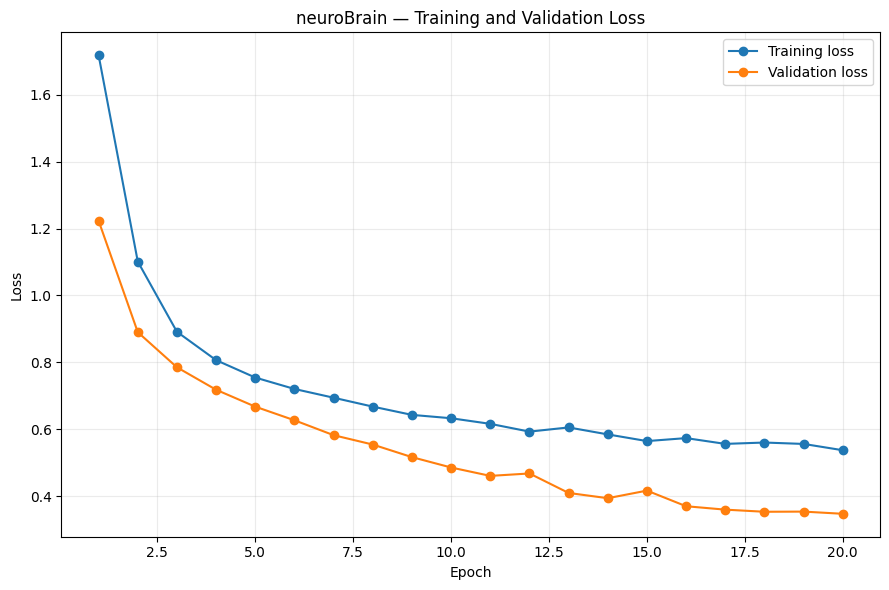

Saved: /kaggle/working/neuroBrain/figures/09_training_validation_loss.png


In [41]:
# TRAINING HISTORY

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


with open(
    TRAINING_HISTORY_PATH,
    "r"
) as f:

    history = json.load(f)


print("TRAINING HISTORY")

print(
    "Type:",
    type(history)
)


# Convert history into a DataFrame

if isinstance(
    history,
    list
):

    history_df = pd.DataFrame(
        history
    )

elif isinstance(
    history,
    dict
):

    # Case 1: dict containing list of records
    record_value = None

    for value in history.values():

        if (
            isinstance(value, list)
            and len(value) > 0
            and isinstance(
                value[0],
                dict
            )
        ):

            record_value = value
            break

    if record_value is not None:

        history_df = pd.DataFrame(
            record_value
        )

    else:

        # Case 2: dictionary of arrays
        history_df = pd.DataFrame(
            history
        )

else:

    raise ValueError(
        "Unknown training history format."
    )


print()
print("History columns:")
print(
    list(history_df.columns)
)

print()
print(
    history_df.head(20)
)


# Save normalized history table

HISTORY_CSV = (
    PROJECT_ROOT
    / "results"
    / "training_history.csv"
)

HISTORY_CSV.parent.mkdir(
    parents=True,
    exist_ok=True
)

history_df.to_csv(
    HISTORY_CSV,
    index=False
)

print()
print(
    "Saved:",
    HISTORY_CSV
)


# Helper for finding columns

def find_column(
    dataframe,
    candidates
):

    for candidate in candidates:

        if candidate in dataframe.columns:

            return candidate

    return None


epoch_col = find_column(
    history_df,
    [
        "epoch",
        "Epoch",
        "epochs"
    ]
)

train_loss_col = find_column(
    history_df,
    [
        "train_loss",
        "training_loss",
        "loss"
    ]
)

val_loss_col = find_column(
    history_df,
    [
        "val_loss",
        "validation_loss"
    ]
)


# Training / validation loss

if (
    epoch_col is not None
    and train_loss_col is not None
):

    plt.figure(
        figsize=(9, 6)
    )

    plt.plot(
        history_df[epoch_col],
        history_df[train_loss_col],
        marker="o",
        label="Training loss"
    )

    if val_loss_col is not None:

        plt.plot(
            history_df[epoch_col],
            history_df[val_loss_col],
            marker="o",
            label="Validation loss"
        )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "neuroBrain — Training and Validation Loss"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()

    path = (
        FIGURES_DIR
        / "09_training_validation_loss.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        path
    )

else:

    print(
        "Training/validation loss columns "
        "could not be automatically identified."
    )

In [42]:
# TRAINING METRIC SUMMARY

print("TRAINING HISTORY — AVAILABLE METRICS")

for column in history_df.columns:

    print(
        f"{column}:",
        history_df[column].dtype
    )


# Display the complete history table
display(
    history_df
)

TRAINING HISTORY — AVAILABLE METRICS
epoch: int64
train_loss: float64
val_loss: float64
class_0_dice: float64
class_1_dice: float64
class_2_dice: float64
class_3_dice: float64
WT_dice: float64
TC_dice: float64
ET_dice: float64
mean_tumor_dice: float64
learning_rate: float64


,epoch,train_loss,val_loss,class_0_dice,class_1_dice,class_2_dice,class_3_dice,WT_dice,TC_dice,ET_dice,mean_tumor_dice,learning_rate
0,1,1.717818,1.223164,0.992749,0.388922,0.093135,0.144097,0.548505,0.209635,0.144097,0.300745,0.0001
1,2,1.101257,0.890173,0.998149,0.550872,0.119177,0.389359,0.787947,0.374724,0.389359,0.517343,0.0001
2,3,0.891252,0.785162,0.997491,0.555845,0.053893,0.421638,0.751487,0.362423,0.421638,0.511849,0.0001
3,4,0.806485,0.718070,0.998195,0.611329,0.049240,0.534460,0.793923,0.496798,0.534460,0.608394,0.0001
4,5,0.754536,0.667528,0.998108,0.622837,0.084492,0.601012,0.786598,0.582272,0.601012,0.656628,0.0001
5,6,0.720412,0.626847,0.998538,0.655594,0.134470,0.608353,0.820684,0.595627,0.608353,0.674888,0.0001
6,7,0.694260,0.582270,0.998496,0.676251,0.239893,0.623036,0.826779,0.694137,0.623036,0.714651,0.0001
7,8,0.667656,0.554257,0.998273,0.656313,0.258460,0.643461,0.802617,0.662713,0.643461,0.702930,0.0001
8,9,0.642956,0.516705,0.998273,0.670546,0.365869,0.643703,0.813902,0.692082,0.643703,0.716562,0.0001
9,10,0.632918,0.485673,0.998444,0.678963,0.423839,0.661191,0.824237,0.712442,0.661191,0.732623,0.0001


In [43]:
# REPRESENTATIVE VALIDATION CASES

patient_items = list(
    patient_results.values()
)

patient_items_sorted = sorted(
    patient_items,
    key=lambda x:
        x["mean_tumor_dice"]
)

n = len(
    patient_items_sorted
)

selected_cases = {

    "challenging":
        patient_items_sorted[
            int(0.10 * (n - 1))
        ],

    "typical":
        patient_items_sorted[
            int(0.50 * (n - 1))
        ],

    "strong":
        patient_items_sorted[
            int(0.90 * (n - 1))
        ],
}


print(
    "Selected representative cases:"
)

for category, item in (
    selected_cases.items()
):

    print(
        category.title(),
        ":",
        item["patient_id"],
        "| Mean Tumor Dice:",
        f"{item['mean_tumor_dice']:.4f}"
    )

Selected representative cases:
Challenging : BRATS_243 | Mean Tumor Dice: 0.4158
Typical : BRATS_464 | Mean Tumor Dice: 0.6587
Strong : BRATS_244 | Mean Tumor Dice: 0.7997


Qualitative cases loaded: 3


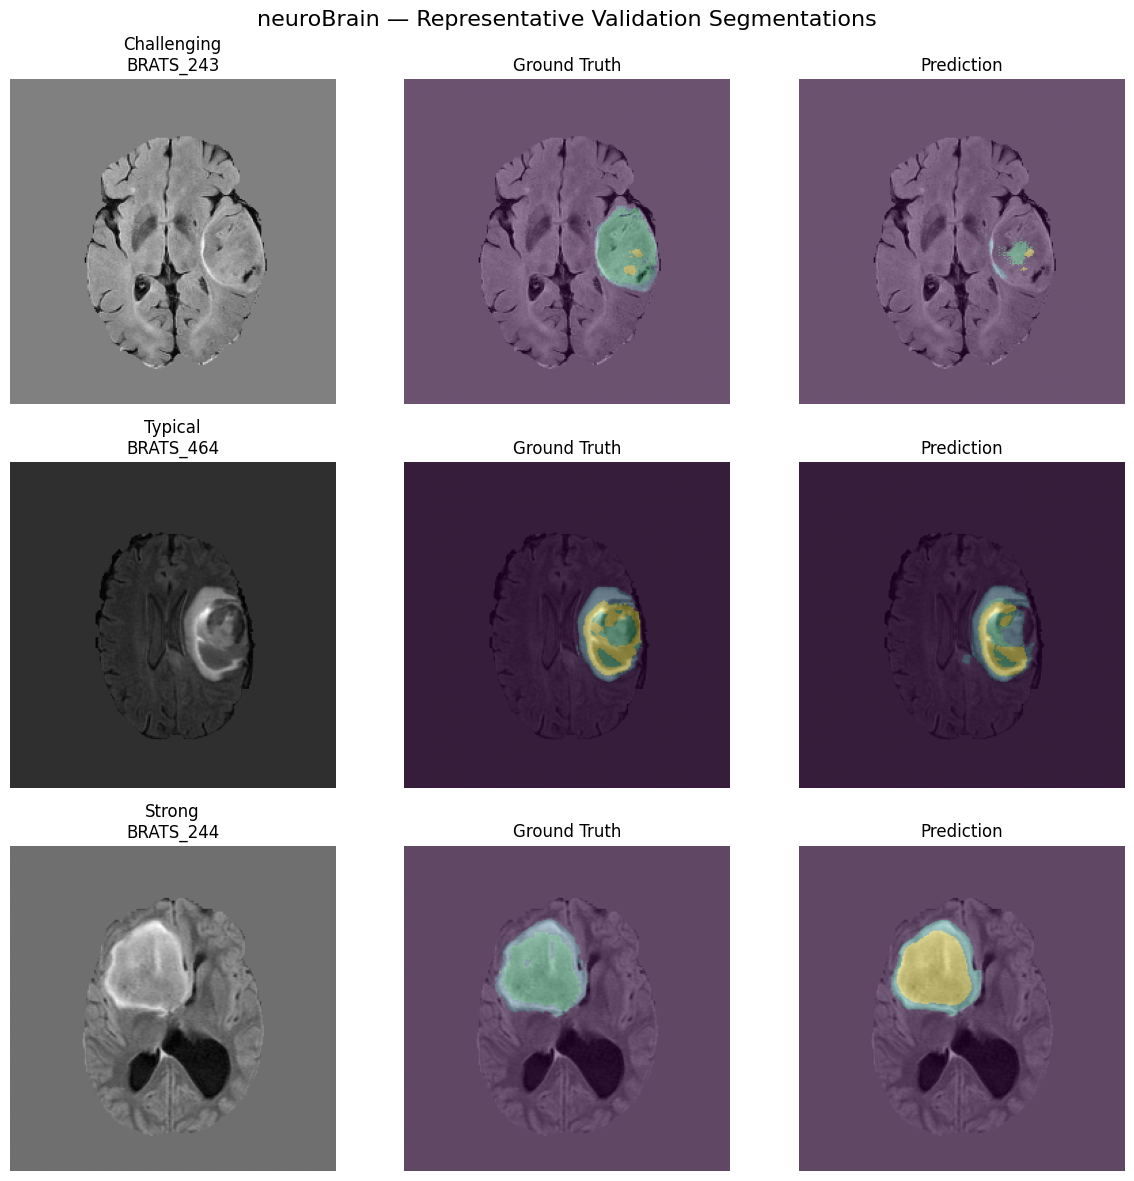

Saved: /kaggle/working/neuroBrain/figures/10_qualitative_segmentation_examples.png


In [44]:
# QUALITATIVE SEGMENTATION

from monai.inferers import sliding_window_inference
import matplotlib.pyplot as plt
import numpy as np
import torch


selected_ids = {
    item["patient_id"]
    for item
    in selected_cases.values()
}


case_data = {}


model.eval()


with torch.no_grad():

    for batch in val_loader:

        images = batch["image"]

        labels = batch["label"]

        patient_ids = batch["patient_id"]


        for i in range(
            len(patient_ids)
        ):

            patient_id = str(
                patient_ids[i]
            )


            if (
                patient_id
                not in selected_ids
            ):

                continue


            image = (
                images[i:i+1]
                .to(device)
            )

            label = (
                labels[i]
                .cpu()
                .numpy()
            )


            logits = (
                sliding_window_inference(
                    inputs=image,
                    roi_size=ROI_SIZE,
                    sw_batch_size=1,
                    predictor=model,
                    overlap=OVERLAP
                )
            )


            prediction = (
                torch.argmax(
                    logits,
                    dim=1
                )[0]
                .cpu()
                .numpy()
            )


            # FLAIR
            
            flair = (
                images[i, 0]
                .cpu()
                .numpy()
            )


            # Select slice with largest GT tumor
            tumor_area = (
                (label > 0)
                .sum(axis=(0, 1))
            )

            slice_idx = int(
                np.argmax(
                    tumor_area
                )
            )


            case_data[
                patient_id
            ] = {

                "flair":
                    flair[
                        :, :,
                        slice_idx
                    ],

                "label":
                    label[
                        :, :,
                        slice_idx
                    ],

                "prediction":
                    prediction[
                        :, :,
                        slice_idx
                    ],

                "slice":
                    slice_idx
            }


            del image
            del logits
            del prediction

            torch.cuda.empty_cache()


        if (
            len(case_data)
            == len(selected_ids)
        ):

            break


print(
    "Qualitative cases loaded:",
    len(case_data)
)


# Plot

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)


for row, (
    case_type,
    metric_data
) in enumerate(
    selected_cases.items()
):

    patient_id = (
        metric_data["patient_id"]
    )

    data = (
        case_data[patient_id]
    )


    # FLAIR
    
    axes[row, 0].imshow(
        data["flair"].T,
        cmap="gray",
        origin="lower"
    )

    axes[row, 0].set_title(
        f"{case_type.title()}\n"
        f"{patient_id}"
    )


    # Ground truth

    axes[row, 1].imshow(
        data["flair"].T,
        cmap="gray",
        origin="lower"
    )

    axes[row, 1].imshow(
        data["label"].T,
        alpha=0.35,
        origin="lower"
    )

    axes[row, 1].set_title(
        "Ground Truth"
    )


    # Prediction

    axes[row, 2].imshow(
        data["flair"].T,
        cmap="gray",
        origin="lower"
    )

    axes[row, 2].imshow(
        data["prediction"].T,
        alpha=0.35,
        origin="lower"
    )

    axes[row, 2].set_title(
        "Prediction"
    )


    for col in range(3):

        axes[
            row,
            col
        ].axis("off")


plt.suptitle(
    "neuroBrain — Representative Validation Segmentations",
    fontsize=16
)

plt.tight_layout()

QUALITATIVE_PATH = (
    FIGURES_DIR
    / "10_qualitative_segmentation_examples.png"
)

plt.savefig(
    QUALITATIVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    QUALITATIVE_PATH
)

In [46]:
# FINAL RESULTS MARKDOWN

FINAL_RESULTS_MD = (
    PROJECT_ROOT
    / "docs"
    / "final_evaluation.md"
)

FINAL_RESULTS_MD.parent.mkdir(
    parents=True,
    exist_ok=True
)


markdown = f"""# neuroBrain — Final Evaluation

## Experiment

- Selected checkpoint: Epoch {checkpoint["epoch"]}
- Stored checkpoint metric: {checkpoint["best_metric"]:.10f}
- Validation patients: 97
- Random seed: {RANDOM_SEED}
- ROI size: {ROI_SIZE}
- Sliding-window overlap: {OVERLAP}

## Final Patient-Level Validation Results

| Metric | Mean Dice | Std | Min | Max |
|---|---:|---:|---:|---:|
"""

for label, key in display_rows:

    result = final_metrics[key]

    markdown += (
        f"| {label} | "
        f"{result['mean']:.4f} | "
        f"{result['std']:.4f} | "
        f"{result['min']:.4f} | "
        f"{result['max']:.4f} |\n"
    )


markdown += """

## Metric Definitions

- Background = class 0.
- Edema = class 1.
- Non-enhancing tumor = class 2.
- Enhancing tumor = class 3.
- Whole Tumor (WT) = labels 1 + 2 + 3.
- Tumor Core (TC) = labels 2 + 3.
- Enhancing Tumor (ET) = label 3.
- Mean Tumor Dice = arithmetic mean of class 1, class 2, and class 3 Dice.

The checkpoint-selection metric is reported separately from Mean Tumor Dice because checkpoint selection uses the composite WT/TC/ET regions.

These results represent the fixed 97-patient validation set and are not hidden test-set results.

## Inference

Inference used MONAI sliding-window inference:

- ROI: 96 × 96 × 96
- Sliding-window batch size: 1
- Overlap: 0.25

## Persistence

The patient-level and aggregate evaluation artifacts are also backed up to the project's Hugging Face checkpoint repository.
"""


with open(
    FINAL_RESULTS_MD,
    "w"
) as f:

    f.write(markdown)


print(
    FINAL_RESULTS_MD
)

print()
print(markdown)

/kaggle/working/neuroBrain/docs/final_evaluation.md

# neuroBrain — Final Evaluation

## Experiment

- Selected checkpoint: Epoch 18
- Stored checkpoint metric: 0.7628627273
- Validation patients: 97
- Random seed: 42
- ROI size: (96, 96, 96)
- Sliding-window overlap: 0.25

## Final Patient-Level Validation Results

| Metric | Mean Dice | Std | Min | Max |
|---|---:|---:|---:|---:|
| Background | 0.9988 | 0.0007 | 0.9964 | 0.9998 |
| Edema | 0.7061 | 0.1401 | 0.2466 | 0.9096 |
| Non-enhancing tumor | 0.4738 | 0.2450 | 0.0000 | 0.9537 |
| Enhancing tumor | 0.7106 | 0.2375 | 0.0000 | 0.9348 |
| Whole Tumor (WT) | 0.8450 | 0.1106 | 0.3540 | 0.9679 |
| Tumor Core (TC) | 0.7352 | 0.2028 | 0.0769 | 0.9690 |
| Enhancing Tumor (ET) | 0.7106 | 0.2375 | 0.0000 | 0.9348 |
| Mean Tumor Dice | 0.6302 | 0.1436 | 0.1426 | 0.8690 |


## Metric Definitions

- Background = class 0.
- Edema = class 1.
- Non-enhancing tumor = class 2.
- Enhancing tumor = class 3.
- Whole Tumor (WT) = labels 1 + 2 + 3.
- T

In [52]:
# FINAL HUGGING FACE BACKUP

from huggingface_hub import HfApi

api = HfApi(
    token=HF_TOKEN
)

print("FINAL HUGGING FACE BACKUP")

# Evaluation artifacts

api.upload_folder(
    folder_path=str(
        FINAL_EVAL_DIR
    ),
    repo_id=HF_REPO_ID,
    repo_type="model",
    path_in_repo=(
        "formal_experiment/"
        "final_evaluation"
    ),
    commit_message=(
        "Save complete 97-patient validation results"
    ),
)

# Training history

api.upload_file(
    path_or_fileobj=str(
        TRAINING_HISTORY_PATH
    ),
    path_in_repo=(
        "formal_experiment/"
        "training_history.json"
    ),
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message=(
        "Preserve training history"
    ),
)

print()
print("FINAL EVALUATION BACKED UP TO HUGGING FACE")

FINAL HUGGING FACE BACKUP


No files have been modified since last commit. Skipping to prevent empty commit.



FINAL EVALUATION BACKED UP TO HUGGING FACE


In [53]:
# VERIFY HUGGING FACE BACKUP

from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id=HF_REPO_ID,
    repo_type="model"
)

print("HUGGING FACE REPOSITORY")

important_files = [
    "formal_experiment/best_model.pt",
    "formal_experiment/latest.pt",
    "formal_experiment/training_history.json",
    "formal_experiment/final_evaluation/patient_metrics.json",
    "formal_experiment/final_evaluation/final_metrics.json",
    "formal_experiment/final_evaluation/evaluation_summary.txt",
]

for required in important_files:

    found = (
        required in files
    )

    print(
        "OK   " if found else "MISSING",
        required
    )

    assert found


print()
print(
    "HUGGING FACE BACKUP VERIFIED."
)

HUGGING FACE REPOSITORY
OK    formal_experiment/best_model.pt
OK    formal_experiment/latest.pt
OK    formal_experiment/training_history.json
OK    formal_experiment/final_evaluation/patient_metrics.json
OK    formal_experiment/final_evaluation/final_metrics.json
OK    formal_experiment/final_evaluation/evaluation_summary.txt

HUGGING FACE BACKUP VERIFIED.


In [54]:
# FINAL REPOSITORY CHECK

import os

os.chdir(
    "/kaggle/working/neuroBrain"
)

print("Final neuroBrain repository")

print()
print("Files:")

for root, dirs, files in os.walk("."):

    # Ignore Git internals
    if ".git" in root.split(os.sep):
        continue

    for file in sorted(files):

        path = os.path.join(
            root,
            file
        )

        print(path)

print()
print("Git status:")

os.system(
    "git status --short"
)

Final neuroBrain repository

Files:
./.gitignore
./LICENSE
./README.md
./requirements.txt
./docs/.gitkeep
./docs/final_evaluation.md
./notebooks/.gitkeep
./notebooks/01_neuroMRI_dataset_exploration.ipynb
./notebooks/02_neuroMRI_preprocessing.ipynb
./notebooks/03_neuroMRI_data_pipeline.ipynb
./notebooks/04_neuroMRI_monai_pipeline.ipynb
./notebooks/05_neuroMRI_data_pipeline_and_visualization.ipynb
./models/.gitkeep
./figures/.gitkeep
./figures/01_modalities_overview.png
./figures/02_normalization_comparison.png
./figures/03_single_patient_class_distribution.png
./figures/04_single_patient_class_distribution_log.png
./figures/05_dataset_class_distribution.png
./figures/06_final_validation_dice.png
./figures/07_tumor_region_dice.png
./figures/08_patient_dice_distribution.png
./figures/09_training_validation_loss.png
./figures/10_qualitative_segmentation_examples.png
./Task01_BrainTumour/._dataset.json
./Task01_BrainTumour/._imagesTr
./Task01_BrainTumour/._imagesTs
./Task01_BrainTumour/._la

0

In [56]:
# LARGE FILE SAFETY CHECK

import subprocess

print("CHECKING FOR LARGE FILES")

result = subprocess.run(
    [
        "bash",
        "-c",
        """
        find . -type f -size +100M \
        ! -path './.git/*' \
        -print
        """
    ],
    text=True,
    capture_output=True
)

print(
    result.stdout
)

if result.stdout.strip():

    print(
        "WARNING: large files found."
    )

else:

    print(
        "No files larger than 100 MB found."
    )

CHECKING FOR LARGE FILES

No files larger than 100 MB found.


In [57]:
# GIT SAFETY CHECK

import subprocess

print("CHECKING GIT-TRACKED LARGE DATA / MODELS")

result = subprocess.run(
    [
        "bash",
        "-c",
        """
        git ls-files |
        grep -E '\\.(pt|pth|nii|nii\\.gz|tar|zip)$'
        || true
        """
    ],
    text=True,
    capture_output=True
)

if result.stdout.strip():

    print(
        "WARNING — potentially large files tracked:"
    )

    print(
        result.stdout
    )

else:

    print(
        "No model/dataset archives are tracked by Git."
    )

CHECKING GIT-TRACKED LARGE DATA / MODELS
No model/dataset archives are tracked by Git.


In [61]:
# GIT STAGING

import subprocess

os.chdir(
    "/kaggle/working/neuroBrain"
)

print("STAGING FINAL neuroBrain PROJECT")


subprocess.run(
    [
        "git",
        "add",
        "README.md",
        "docs/",
        "figures/",
        "notebooks/",
        "src/",
        "scripts/",
        "requirements.txt",
        "LICENSE",
        ".gitignore"
    ],
    check=True
)

print("Adding results/ (force-add because it is ignored)...") 

subprocess.run( 
    [ 
        "git",
        "add",
        "-f",
        "results/",
    ],
    check=True,
)

print()
print("STAGED FILES:")
print()

subprocess.run(
    [
        "git",
        "status",
        "--short"
    ],
    check=False
)

STAGING FINAL neuroBrain PROJECT
Adding results/ (force-add because it is ignored)...

STAGED FILES:



CompletedProcess(args=['git', 'status', '--short'], returncode=0)

In [62]:
# REVIEW STAGED CHANGES

print("STAGED DIFF SUMMARY")

os.system(
    "git diff --cached --stat"
)

print()

print("README DIFF")

os.system(
    "git diff --cached -- README.md"
)

STAGED DIFF SUMMARY

README DIFF


0

In [64]:
import subprocess

# Configure Git identity for this repository
subprocess.run(
    [
        "git",
        "config",
        "user.name",
        "Shashi"
    ],
    check=True
)

subprocess.run(
    [
        "git",
        "config",
        "user.email",
        "173938981+ethicalcod@users.noreply.github.com"
    ],
    check=True
)

print("Git identity configured.")

Git identity configured.


In [65]:
import subprocess

subprocess.run(
    ["git", "config", "--get", "user.name"],
    check=True
)

subprocess.run(
    ["git", "config", "--get", "user.email"],
    check=True
)

CompletedProcess(args=['git', 'config', '--get', 'user.email'], returncode=0)

In [66]:
import subprocess

name_result = subprocess.run(
    ["git", "config", "--get", "user.name"],
    text=True,
    capture_output=True,
    check=True
)

email_result = subprocess.run(
    ["git", "config", "--get", "user.email"],
    text=True,
    capture_output=True,
    check=True
)

print("Git name :", name_result.stdout.strip())
print("Git email:", email_result.stdout.strip())

Git name : Shashi
Git email: 173938981+ethicalcod@users.noreply.github.com


In [67]:
# FINAL GIT COMMIT


import subprocess

commit_message = (
    "Complete formal training and final validation"
)

result = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        commit_message
    ],
    text=True
)

if result.returncode != 0:

    raise RuntimeError(
        "Git commit failed."
    )

print()
print(
    "FINAL COMMIT CREATED."
)


FINAL COMMIT CREATED.


In [69]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

GITHUB_TOKEN = user_secrets.get_secret("GITHUB_TOKEN")

print("GitHub token loaded:", GITHUB_TOKEN is not None)

GitHub token loaded: True


In [71]:
# GITHUB PUSH FROM KAGGLE

import subprocess
from kaggle_secrets import UserSecretsClient

# Configuration

GITHUB_USERNAME = "ethicalcod"
REPO_NAME = "neuroBrain"

# Get GitHub token from Kaggle Secret

user_secrets = UserSecretsClient()

GITHUB_TOKEN = user_secrets.get_secret(
    "GITHUB_TOKEN"
)

if not GITHUB_TOKEN:
    raise RuntimeError(
        "GITHUB_TOKEN was not found in Kaggle Secrets."
    )


# Configure authenticated remote

authenticated_url = (
    f"https://{GITHUB_USERNAME}:{GITHUB_TOKEN}"
    f"@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
)

subprocess.run(
    [
        "git",
        "remote",
        "set-url",
        "origin",
        authenticated_url,
    ],
    check=True,
)

# Push

print("Pushing final neuroBrain project...")

result = subprocess.run(
    [
        "git",
        "push",
        "origin",
        "main",
    ],
    text=True,
    capture_output=True,
)

# Handle result

if result.returncode != 0:

    print("Git push failed.")
    print()
    print(result.stderr)

    raise RuntimeError(
        "Git push failed."
    )


print()
print(result.stdout)
print("GITHUB PUSH COMPLETED.")

Pushing final neuroBrain project...


GITHUB PUSH COMPLETED.


In [73]:
# Restore unauthenticated GitHub URL after successful push

clean_url = (
    f"https://github.com/"
    f"{"ethicalcod"}/"
    f"{"neuroBrain"}.git"
)

subprocess.run(
    [
        "git",
        "remote",
        "set-url",
        "origin",
        clean_url,
    ],
    check=True,
)

print("Clean GitHub remote restored.")

Clean GitHub remote restored.


In [75]:
import subprocess

result = subprocess.run(
    ["git", "config", "--get", "remote.origin.url"],
    text=True,
    capture_output=True,
    check=True
)

url = result.stdout.strip()

# Hide any possible credentials before displaying
if "@" in url:
    url = url.split("@", 1)[1]
    url = "https://" + url

print("GitHub remote:", url)

GitHub remote: https://github.com/ethicalcod/neuroBrain.git


In [76]:
# FINAL PROJECT VERIFICATION

import subprocess
import json

print("neuroBrain — FINAL PROJECT VERIFICATION")

# Git

print()
print("GIT STATUS:")

subprocess.run(
    [
        "git",
        "status"
    ],
    check=False
)


print()
print("LATEST COMMIT:")

subprocess.run(
    [
        "git",
        "log",
        "-1",
        "--oneline"
    ],
    check=False
)


# Final metrics

with open(
    FINAL_METRICS_PATH
) as f:

    metrics = json.load(f)


print()
print("FINAL VALIDATION")

print(
    "Checkpoint:",
    metrics[
        "metadata"
    ][
        "checkpoint_epoch"
    ]
)

print(
    "Patients:",
    metrics[
        "metadata"
    ][
        "num_validation_patients"
    ]
)

print(
    "Background:",
    f"{metrics['class_0_dice']['mean']:.4f}"
)

print(
    "Edema:",
    f"{metrics['class_1_dice']['mean']:.4f}"
)

print(
    "Non-enhancing tumor:",
    f"{metrics['class_2_dice']['mean']:.4f}"
)

print(
    "Enhancing tumor:",
    f"{metrics['class_3_dice']['mean']:.4f}"
)

print(
    "WT:",
    f"{metrics['WT_dice']['mean']:.4f}"
)

print(
    "TC:",
    f"{metrics['TC_dice']['mean']:.4f}"
)

print(
    "ET:",
    f"{metrics['ET_dice']['mean']:.4f}"
)

print(
    "Mean Tumor Dice:",
    f"{metrics['mean_tumor_dice']['mean']:.4f}"
)


print()
print("neuroBrain FINALIZATION COMPLETE")


neuroBrain — FINAL PROJECT VERIFICATION

GIT STATUS:

LATEST COMMIT:

FINAL VALIDATION
Checkpoint: 18
Patients: 97
Background: 0.9988
Edema: 0.7061
Non-enhancing tumor: 0.4738
Enhancing tumor: 0.7106
WT: 0.8450
TC: 0.7352
ET: 0.7106
Mean Tumor Dice: 0.6302

neuroBrain FINALIZATION COMPLETE


In [79]:
from datetime import datetime

modified_time = datetime.fromtimestamp(
    README_PATH.stat().st_mtime
)

print(
    "README last modified:",
    modified_time
)

print(
    "README size:",
    README_PATH.stat().st_size,
    "bytes"
)

README last modified: 2026-09-20 19:21:05.586321
README size: 5967 bytes
